# Tutorial: Phenomenological Model

Welcome to the second **QPyD** tutorial. 

While the `DerivedParameters` model builds the system from microscopic single-particle orbitals and Coulomb interactions using Exact Diagonalization, the `DirectParameters` class allows you to **bypass this entirely**.

In this phenomenological model, you explicitly define the many-body states, their energies, and the transition rates between them. This is very useful for quickly testing theoretical hypotheses for fitting experimental data or analyzing arbitrary macroscopic behaviors without the computational overhead of a full Hamiltonian diagonalization.

## 1. Imports
Let's import the core classes. Notice that we are importing `DirectParameters` instead of `DerivedParameters` this time.

In [1]:
from qpyd import DirectParameters, Simulator, Plotter

## 2. Defining Charge Sectors and Energies

Instead of defining orbitals, we define the exact many-body states that exist within each charge sector. By providing a string label (e.g., `'CS'` for Closed-Shell Singlet, `'D'` for Doublet), the engine automatically determines the statistical degeneracy weights for transitions.

In [2]:
charge_numbers = [0, 1, 2]

# Format: [(Energy in meV, Spin Label), ...]
energies = [
    [(0.0, 'CS')],               # N=0: 1 state  (S=0, Degeneracy = 1)
    [(0.5, 'D'), (1.1, 'D')],    # N=1: 2 states (S=1/2, Degeneracy = 2)
    [(2.0, 'CS')]                # N=2: 1 state  (S=0, Degeneracy = 1)
]

# If spin_rules are disabled (look step 4.), we can simply create a list of energies as [E1, E2, ...]

## 3. Defining State-Dependent Tunneling Matrices

Because we explicitly defined the states, we must define exactly how strongly they couple to the leads. 

The coupling matrices are organized by charge transition. For a transition from $N \rightarrow N+1$, the matrix shape must be `(M_{N+1} x M_N)`. For example, jumping from the 1 state in $N=0$ to the 2 states in $N=1$ requires a $(2 \times 1)$ matrix.

In [3]:
# -------------------------------------------------------------
# Transition A: N=0 -> N=1 
# Matrix shape must be (M_1 x M_0) -> (2 x 1)
# Let's couple strongly to the N=1 ground state, weakly to the excited state.
gL_0to1 = [
    [1.0],  # Coupling: N=0 Empty -> N=1 Ground
    [2.0]   # Coupling: N=0 Empty -> N=1 Excited
]
gR_0to1 = [
    [0.1],  
    [0.2]   
]

# -------------------------------------------------------------
# Transition B: N=1 -> N=2 
# Matrix shape must be (M_2 x M_1) -> (1 x 2)
# Let's make the N=1 Ground -> N=2 transition strong, but N=1 Excited -> N=2 forbidden (0.0).
gL_1to2 = [
    [2.0, 1.0]  # [Coupling from N=1 Ground, Coupling from N=1 Excited]
]
gR_1to2 = [
    [0.2, 0.1]  
]

# Group them into a list of length (len(charge_numbers) - 1)
gammas_state_dependent = [
    [gL_0to1, gR_0to1],  # Jump 1 (N=0 to N=1)
    [gL_1to2, gR_1to2]   # Jump 2 (N=1 to N=2)
]

# We can also set global tunnel couplings for all the transitions in the form [gamma_L, gamma_R]

## 4. Initialize Parameters and Simulator

We pass these explicitly constructed states and rates into `DirectParameters`. Notice that we activate `spin_labels=True` so the simulator applies the proper Clebsch-Gordan transition weights analytically.

In [4]:
params = DirectParameters(
    charge_numbers=charge_numbers,
    energies=energies,
    T=0.1,
    lever_arms=[0.3, 0.3, 0.4],     # Capacitive lever arms [a_L, a_R, a_G]
    gammas=gammas_state_dependent,  
    gamma_rel=0.0,                  # Explicit relaxation rate between states of same charge
    spin_labels=True,               # Use 'CS', 'D', 'T' string labels for degeneracy
    setup="symmetric",
    datapoints=300                  # 300x300 high-resolution grid
)

sim = Simulator(params)
plotter = Plotter()

### Reviewing the Configuration
The parameter object automatically calculates the necessary voltage windows and lever arms based on the energy scales we provided. However, it might be more convenient to specify our own ranges. This can easily be done by specifying the parameters `Vg_range` and `Vb_range` which take the form `[min_val, max_val, num_points]`.

 We can inspect these internal configurations easily:

In [5]:
params.params_config

{'Occupations & Energies': {0: [{'energy': 0.0, 'label': 'CS'}],
  1: [{'energy': 0.5, 'label': 'D'}, {'energy': 1.1, 'label': 'D'}],
  2: [{'energy': 2.0, 'label': 'CS'}]},
 'Lead Tunnel Couplings [Γ_L, Γ_R]': [[[[1.0], [2.0]], [[0.1], [0.2]]],
  [[[2.0, 1.0]], [[0.2, 0.1]]]],
 'Relaxation Rate(s) Γ_rel': 0.0,
 'Spin Degeneracy Rules': 'Active',
 'Coulomb Diamond Slopes [s1, s2]': 'N/A (Using lever arms)',
 'Lever Arms [a_L, a_R, a_G]': [0.3, 0.3, 0.4],
 'Temperature': 0.1,
 'V_g range': [0.438, 4.562],
 'V_b range': [-0.75, 0.75],
 'Bias-voltage Setup': 'symmetric'}

## 5. Execute Solver and Visualize

We are evaluating a dense $300 \times 300$ grid ($90,000$ points). We use `batch_size=1000` to stream it safely into memory. 

Starting solver (Total points: 9.00e+04, Total parameters: 3.60e+05)...
Solved full grid in 0.95s.


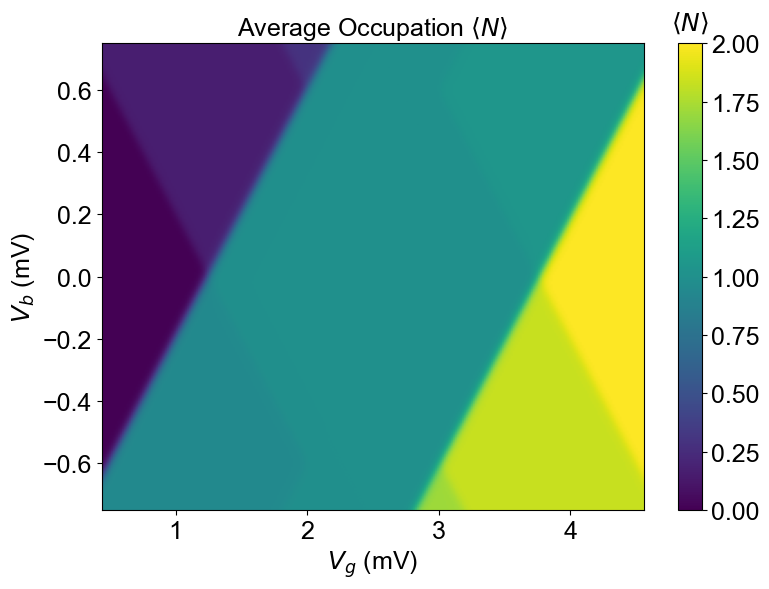

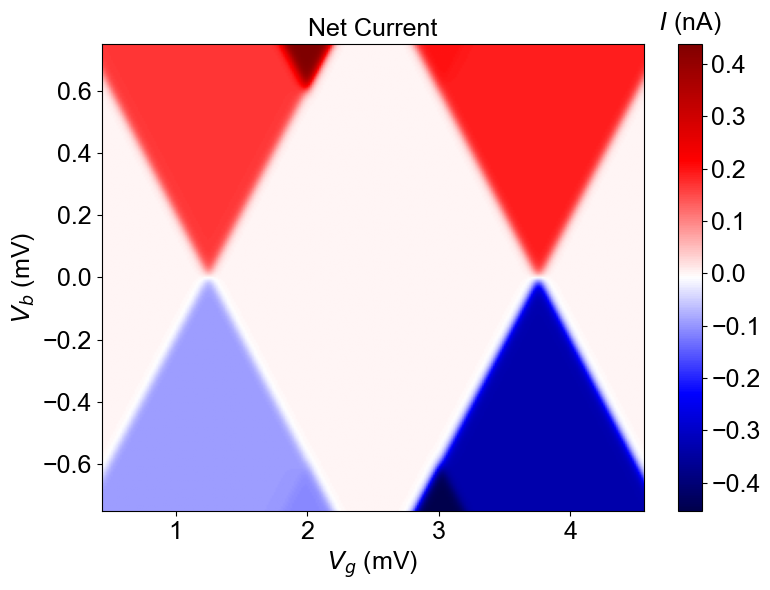

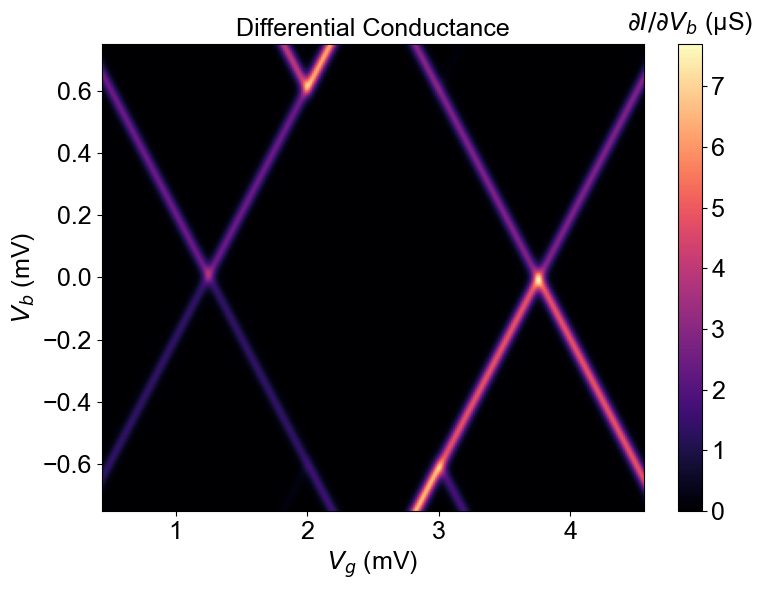

<Axes: title={'center': '$V_b \\approx 0.499$ mV'}, xlabel='$V_g$ (mV)', ylabel='$\\partial I / \\partial V_b$ (μS)'>

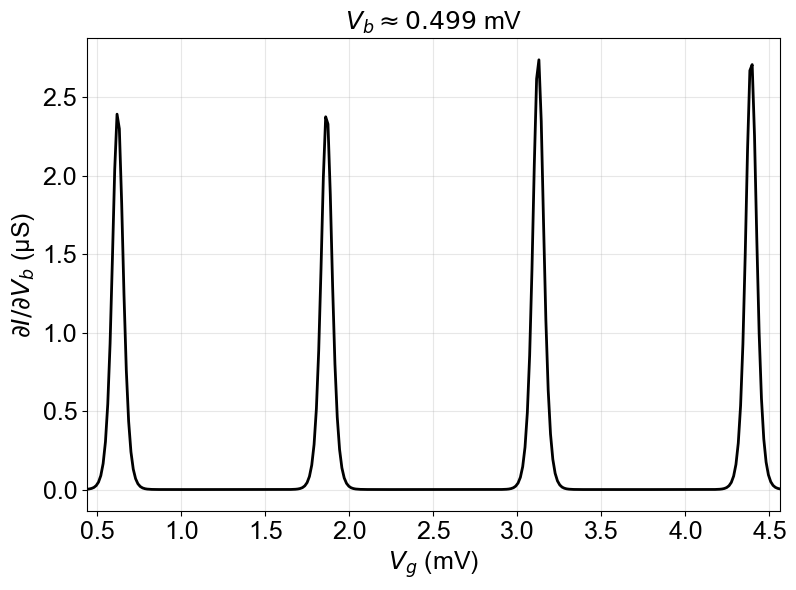

In [6]:
# Solve the master equation across the 300x300 grid
sim.solve(batch_size=1000)

# Pull the evaluated arrays back from JAX memory
results = sim.get_results()

# Define the physical axes limits for the plot
extent = [params.Vgmin, params.Vgmax, params.Vbmin, params.Vbmax]

# Define the axes units and the units of the quantities to be plotted
axes_units = ['mV', 'mV']
curr_unit = 'nA'
conductance_unit = 'μS'

# 1. Plot the Average Charge Occupation
plotter.plot_map(results=results, 
                 quantity='N_avg', 
                 extent=extent, 
                 title="Average Occupation $\\langle N \\rangle$",
                 axes_units=axes_units
                 )

# 2. Plot the DC Current
plotter.plot_map(results=results, 
                 quantity='I', 
                 extent=extent, 
                 title="Net Current",
                 axes_units=axes_units,
                 quantity_units=curr_unit)

# 3. Plot the Differential Conductance
plotter.plot_map(results=results, 
                 quantity='G', 
                 extent=extent, 
                 title="Differential Conductance",
                 axes_units=axes_units,
                 quantity_units=conductance_unit)

# 4. Plot a slice at a constant bias
plotter.plot_slice(results=results, 
                   quantity='G', 
                   fixed_value=0.5,
                   cut_type='horizontal',
                   axes_units=axes_units,
                   quantity_units=conductance_unit
                   )